# Setup: imports, seeds, and device
Load core libraries, enable reproducibility, and select the compute device.

In [ ]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

# metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import pearsonr

# AMP (mixed precision)
from torch.cuda.amp import GradScaler, autocast

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


# Configuration: data paths and hyperparameters

In [ ]:
DATA_DIR = r"C:\Users\Ayaan\Desktop\dl\Dataset"  # e.g., "/content/Dataset" or "C:\\Users\\you\\Dataset"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOT_DIR = os.path.join(DATA_DIR, "annotations")

# Training hyperparams
NUM_CLASSES = 8
BATCH_SIZE = 32              # reduce to 16 if OOM
NUM_EPOCHS = 25              # adjust per your time budget
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0              # 0 is safest on Windows / avoids 0% progress hangs
PIN_MEMORY = torch.cuda.is_available()
LOSS_REG_WEIGHT = 0.5        # weight for valence/arousal regression loss

print("Images dir:", IMAGES_DIR)
print("Annots dir:", ANNOT_DIR)

Images dir: C:\Users\Ayaan\Desktop\dl\Dataset\images
Annots dir: C:\Users\Ayaan\Desktop\dl\Dataset\annotations


# Metric helpers
Utility functions for RMSE, sign agreement, and concordance correlation coefficient (CCC).

In [ ]:
"""Root Mean Squared Error for continuous targets."""
def rmse(y_true, y_pred): 
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


"""Proportion of predictions with the same sign as ground truth."""
def sign_agreement(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

"""Concordance correlation coefficient measuring agreement."""
def concordance_ccc(y_true, y_pred):
    x = np.asarray(y_true); y = np.asarray(y_pred)
    if x.size == 0:
        return 0.0
    x_mean, y_mean = x.mean(), y.mean()
    cov = np.mean((x - x_mean) * (y - y_mean))
    var_x = np.mean((x - x_mean) ** 2)
    var_y = np.mean((y - y_mean) ** 2)
    denom = var_x + var_y + (x_mean - y_mean) ** 2
    if denom == 0:
        return 1.0
    return float(2 * cov / denom)

# Dataset
A custom Dataset of 4000 images that loads images and their corresponding expression, valence, and arousal annotations.

In [4]:
class AffectDataset(Dataset):
    def __init__(self, image_paths, annotations_dir, transform=None):
        self.image_paths = image_paths
        self.annotations_dir = annotations_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def _load_annotation(self, base_idx, suffix):
        f = os.path.join(self.annotations_dir, f"{base_idx}_{suffix}.npy")
        if not os.path.exists(f):
            return None
        return np.load(f, allow_pickle=True)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base = Path(img_path).stem

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        exp = self._load_annotation(base, "exp")
        val = self._load_annotation(base, "val")
        aro = self._load_annotation(base, "aro")

        def to_scalar(x, default=0.0):
            if x is None:
                return default
            arr = np.array(x)
            return float(arr.item()) if arr.shape == () else float(arr[0])

        # expression default -1, but CrossEntropy requires 0..NUM_CLASSES-1; ensure valid labels exist in split
        if exp is None:
            exp_label = 0
        else:
            arr = np.array(exp)
            exp_label = int(arr.item()) if arr.shape == () else int(arr[0])

        return {
            "image": image,
            "exp": torch.tensor(exp_label, dtype=torch.long),
            "valence": torch.tensor(to_scalar(val), dtype=torch.float32),
            "arousal": torch.tensor(to_scalar(aro), dtype=torch.float32),
        }

# Data discovery and split
Filter images to those with all required annotations and create a stratified train/validation split.

In [ ]:
# Gather images that have all needed annotations
all_images = sorted([str(p) for p in Path(IMAGES_DIR).glob("*.jpg")])
valid_images, labels = [], []

for p in all_images:
    base = Path(p).stem
    exp_f = os.path.join(ANNOT_DIR, f"{base}_exp.npy")
    val_f = os.path.join(ANNOT_DIR, f"{base}_val.npy")
    aro_f = os.path.join(ANNOT_DIR, f"{base}_aro.npy")
    if os.path.exists(exp_f) and os.path.exists(val_f) and os.path.exists(aro_f):
        valid_images.append(p)
        arr = np.array(np.load(exp_f, allow_pickle=True))
        labels.append(int(arr.item()) if arr.shape == () else int(arr[0]))

print("Total images found:", len(all_images))
print("Images with required annotations:", len(valid_images))


# Stratified split into train and validation sets (80-20)
train_paths, val_paths = train_test_split(
    valid_images,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)
print("Train:", len(train_paths), "Val:", len(val_paths))

Total images found: 3999
Images with required annotations: 3999
Train: 3199 Val: 800


# Transforms and DataLoaders
Define data augmentation for training, normalization for validation, and create DataLoaders.

In [ ]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_ds = AffectDataset(train_paths, ANNOT_DIR, transform=train_transform)
val_ds   = AffectDataset(val_paths,   ANNOT_DIR, transform=val_transform)

# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))

Train batches: 100 Val batches: 25


# Model: backbones and multi-task heads
Backbones (ResNet50, EfficientNet-B3, VGG16, MobileNetV2) with classification and regression heads.

In [ ]:
class Identity(nn.Module):
    """Utility layer that returns input unchanged (used to remove classifier heads)."""
    def forward(self, x):
        return x

class MultiTaskModel(nn.Module):
    """Shared CNN backbone with dual heads: classification (NUM_CLASSES) and regression (2)."""
    def __init__(self, backbone_name="resnet50", pretrained=True, dropout_p=0.4):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == "resnet50":
            self.backbone = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.fc.in_features
            self.backbone.fc = Identity()

        elif backbone_name == "efficientnet_b3":
            # Use EfficientNet-B3 per instructions
            self.backbone = models.efficientnet_b3(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.classifier[1].in_features
            # Replace classifier to expose features; we'll handle pooling manually
            self.backbone.classifier = Identity()

        elif backbone_name == "vgg16":
            self.backbone = models.vgg16(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.classifier[6].in_features  # 4096
            self.backbone.classifier[6] = Identity()

        elif backbone_name == "mobilenet_v2":
            self.backbone = models.mobilenet_v2(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.classifier[1].in_features
            self.backbone.classifier = Identity()

        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}")

        self.feature_dim = dim

        # classification head (8 classes)
        # classification head
        self.cls_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),   # was 0.4 before
            nn.Linear(512, NUM_CLASSES)
        )

        # regression head (2 outputs: valence, arousal)
        self.reg_head = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),   # was 0.4 before
            nn.Linear(256, 2)
        )

    def forward(self, x):
        if self.backbone_name.startswith("efficientnet_"):
            # EfficientNet feature path: features -> GAP -> flatten  
            feats = self.backbone.features(x)
            feats = nn.functional.adaptive_avg_pool2d(feats, 1).reshape(x.shape[0], -1)
        else:
            feats = self.backbone(x)
            feats = feats.view(feats.size(0), -1)

        cls_logits = self.cls_head(feats)
        reg_out = self.reg_head(feats)
        return cls_logits, reg_out

# Training and validation loops
Mixed-precision training with gradient clipping; validation computes classification and regression metrics.

In [ ]:
ce_loss = nn.CrossEntropyLoss(label_smoothing=0.1)  # classification with label smoothing
mse_loss = nn.MSELoss()  # regression

def train_one_epoch(model, loader, optimizer, scaler, epoch, device):
    """One epoch of mixed-precision training with gradient clipping."""
    model.train()
    total_loss, iters = 0.0, 0
    for batch in tqdm(loader, desc=f"Train E{epoch}"):
        imgs = batch["image"].to(device, non_blocking=True)
        labels = batch["exp"].to(device, non_blocking=True)
        reg_target = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits, reg_out = model(imgs)
            loss_cls = ce_loss(logits, labels)
            loss_reg = mse_loss(reg_out, reg_target)
            loss = loss_cls + LOSS_REG_WEIGHT * loss_reg
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        iters += 1
    return total_loss / max(iters, 1)

def validate(model, loader, device):
    """Run validation and compute classification/regression metrics."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    all_val, all_aro, pred_val, pred_aro = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validate"):
            imgs = batch["image"].to(device, non_blocking=True)
            labels = batch["exp"].cpu().numpy()
            valence = batch["valence"].cpu().numpy()
            arousal = batch["arousal"].cpu().numpy()

            logits, reg_out = model(imgs)
            probs = nn.functional.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            reg_np = reg_out.cpu().numpy()

            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.tolist())
            all_val.extend(valence.tolist()); all_aro.extend(arousal.tolist())
            pred_val.extend(reg_np[:, 0].tolist()); pred_aro.extend(reg_np[:, 1].tolist())

    metrics = {
        "acc": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro"),
        "kappa": cohen_kappa_score(all_labels, all_preds),
        "auc_ovr": np.nan,
        "val_rmse": rmse(all_val, pred_val),
        "aro_rmse": rmse(all_aro, pred_aro),
        "val_corr": pearsonr(np.array(all_val), np.array(pred_val))[0] if len(all_val) > 1 else 0.0,
        "aro_corr": pearsonr(np.array(all_aro), np.array(pred_aro))[0] if len(all_aro) > 1 else 0.0,
        "val_sagr": sign_agreement(all_val, pred_val),
        "aro_sagr": sign_agreement(all_aro, pred_aro),
        "val_ccc": concordance_ccc(all_val, pred_val),
        "aro_ccc": concordance_ccc(all_aro, pred_aro),
    }
    # AUC-OVR may fail if a class is missing in predictions; guard it
    try:
        y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
        metrics["auc_ovr"] = roc_auc_score(y_bin, np.array(all_probs), average="macro", multi_class="ovr")
    except Exception:
        metrics["auc_ovr"] = float("nan")
    return metrics

# Training wrapper
Train a selected backbone with CosineAnnealingLR, track history, and save the best checkpoint by CCC.

In [ ]:
def train_model(backbone_name="resnet50", epochs=NUM_EPOCHS, save_path="./best_model.pth"):
    """Train one backbone end-to-end and persist the best checkpoint (by avg CCC)."""
    model = MultiTaskModel(backbone_name=backbone_name, pretrained=True).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = GradScaler()

    best_score = None
    history = {"train_loss": [], "val_acc": [], "val_f1": [], "val_ccc_avg": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler, epoch, DEVICE)
        val_metrics = validate(model, val_loader, DEVICE)
        ccc_avg = 0.5 * (val_metrics["val_ccc"] + val_metrics["aro_ccc"])

        print(f"Epoch {epoch} | Train loss: {train_loss:.4f} | "
              f"Val acc: {val_metrics['acc']:.4f} | Val F1: {val_metrics['f1_macro']:.4f} | "
              f"Val CCC(avg): {ccc_avg:.4f}")

        scheduler.step()  # cosine annealing style
                        # step on train loss (simple, stable)

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1_macro"])
        history["val_ccc_avg"].append(ccc_avg)

        # Save best model by avg CCC
        if best_score is None or ccc_avg > best_score:
            best_score = ccc_avg
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_metrics": val_metrics,
            }, save_path)
            print("Saved best model to", save_path)

    return save_path, history

# Train: ResNet-50
Run training for the ResNet-50 backbone and store the best checkpoint/history.

In [10]:
# Train ResNet50
resnet_ckpt, resnet_hist = train_model(backbone_name="resnet50", epochs=NUM_EPOCHS, save_path="./best_resnet50.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\903451234.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.39it/s]


Epoch 1 | Train loss: 2.0903 | Val acc: 0.3538 | Val F1: 0.3338 | Val CCC(avg): 0.2432
Saved best model to ./best_resnet50.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.59it/s]


Epoch 2 | Train loss: 1.8848 | Val acc: 0.3387 | Val F1: 0.3153 | Val CCC(avg): 0.2936
Saved best model to ./best_resnet50.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.68it/s]


...

Epoch 23 | Train loss: 0.7222 | Val acc: 0.4950 | Val F1: 0.4968 | Val CCC(avg): 0.4995


Train E24:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.36it/s]


Epoch 24 | Train loss: 0.7074 | Val acc: 0.4938 | Val F1: 0.4947 | Val CCC(avg): 0.4968


Train E25:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.38it/s]

Epoch 25 | Train loss: 0.7125 | Val acc: 0.5100 | Val F1: 0.5112 | Val CCC(avg): 0.4990


# Train: EfficientNet-B3
Run training for EfficientNet-B3 and save outputs.

In [11]:
# Train EfficientNet-B3 (per instructions)
effb3_ckpt, effb3_hist = train_model(backbone_name="efficientnet_b3", epochs=NUM_EPOCHS, save_path="./best_efficientnet_b3.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\903451234.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.46it/s]


Epoch 1 | Train loss: 2.0971 | Val acc: 0.3625 | Val F1: 0.3495 | Val CCC(avg): 0.2892
Saved best model to ./best_efficientnet_b3.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.91it/s]


Epoch 2 | Train loss: 1.8372 | Val acc: 0.4037 | Val F1: 0.3917 | Val CCC(avg): 0.3701
Saved best model to ./best_efficientnet_b3.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.77it/s]


...

Epoch 23 | Train loss: 0.5836 | Val acc: 0.4700 | Val F1: 0.4675 | Val CCC(avg): 0.4891


Train E24:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 10.36it/s]


Epoch 24 | Train loss: 0.5892 | Val acc: 0.4713 | Val F1: 0.4701 | Val CCC(avg): 0.4829


Train E25:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 10.48it/s]

Epoch 25 | Train loss: 0.5915 | Val acc: 0.4738 | Val F1: 0.4740 | Val CCC(avg): 0.4837


# Train: VGG16
Train VGG16 and record results.

In [12]:
# Train VGG16
vgg_ckpt, vgg_hist = train_model(backbone_name="vgg16", epochs=NUM_EPOCHS, save_path="./best_vgg16.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\903451234.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:11<00:00,  2.12it/s]


Epoch 1 | Train loss: 2.3323 | Val acc: 0.1237 | Val F1: 0.0278 | Val CCC(avg): 0.0072
Saved best model to ./best_vgg16.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:11<00:00,  2.22it/s]


Epoch 2 | Train loss: 2.3387 | Val acc: 0.1375 | Val F1: 0.0836 | Val CCC(avg): -0.0096


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:11<00:00,  2.25it/s]


...

Epoch 23 | Train loss: 1.7633 | Val acc: 0.3825 | Val F1: 0.3626 | Val CCC(avg): 0.2955


Train E24:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:11<00:00,  2.22it/s]


Epoch 24 | Train loss: 1.7519 | Val acc: 0.3825 | Val F1: 0.3629 | Val CCC(avg): 0.2985


Train E25:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:11<00:00,  2.22it/s]

Epoch 25 | Train loss: 1.7462 | Val acc: 0.3900 | Val F1: 0.3707 | Val CCC(avg): 0.2982


# Train: MobileNetV2
Train MobileNetV2 and record results.

In [13]:
# Train MobileNetV2
mobilenet_ckpt, mobilenet_hist = train_model(backbone_name="mobilenet_v2", epochs=NUM_EPOCHS, save_path="./best_mobilenet_v2.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\903451234.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 10.45it/s]


Epoch 1 | Train loss: 2.1164 | Val acc: 0.3100 | Val F1: 0.2540 | Val CCC(avg): 0.2633
Saved best model to ./best_mobilenet_v2.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 11.26it/s]


Epoch 2 | Train loss: 1.8564 | Val acc: 0.3850 | Val F1: 0.3664 | Val CCC(avg): 0.3543
Saved best model to ./best_mobilenet_v2.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 11.57it/s]


...

Epoch 23 | Train loss: 0.6724 | Val acc: 0.4688 | Val F1: 0.4662 | Val CCC(avg): 0.4881


Train E24:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 11.46it/s]


Epoch 24 | Train loss: 0.6777 | Val acc: 0.4750 | Val F1: 0.4725 | Val CCC(avg): 0.4883


Train E25:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_20324\1781484169.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00, 11.35it/s]

Epoch 25 | Train loss: 0.6743 | Val acc: 0.4738 | Val F1: 0.4700 | Val CCC(avg): 0.4899


# Visualization and evaluation utilities
Plot training history across epochs for the 4 models.

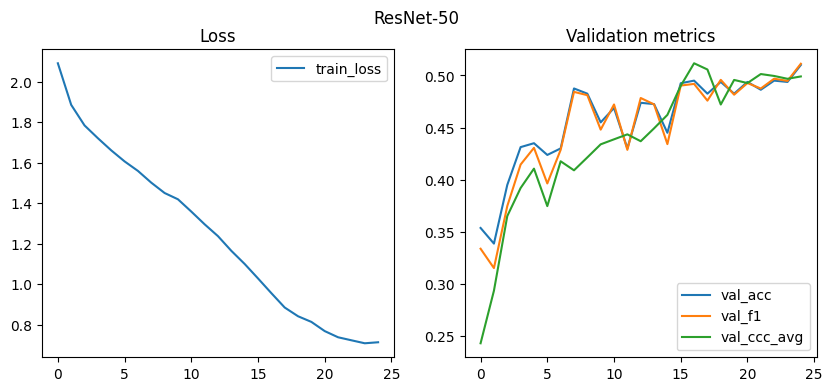

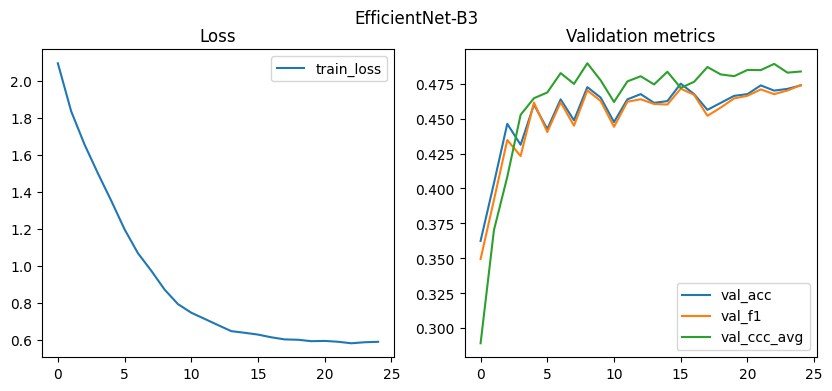

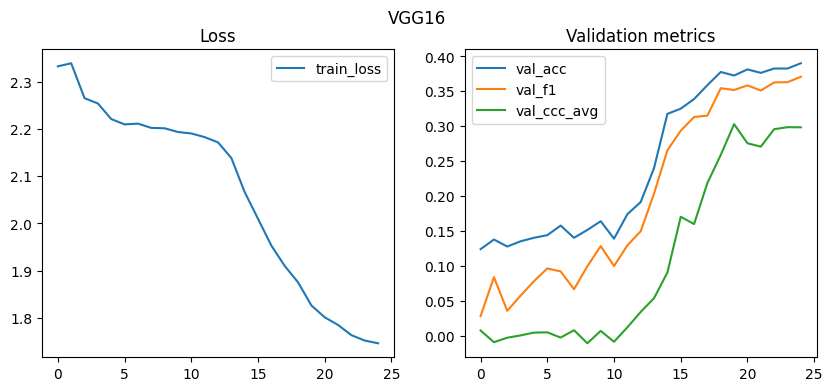

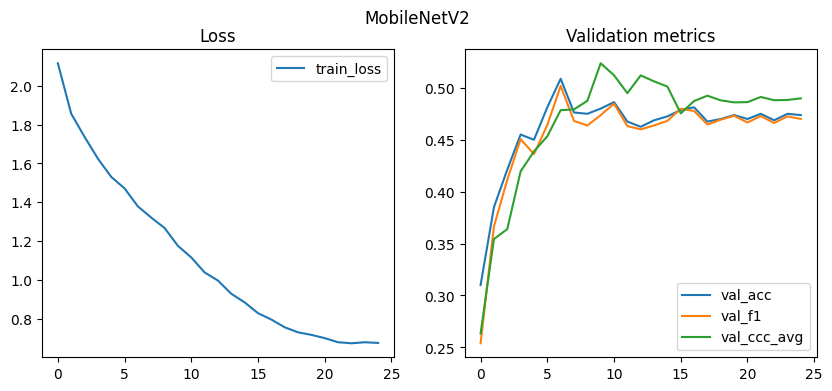

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training curves"):
    """Plot training loss and key validation metrics across epochs."""
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.title("Loss"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["val_acc"], label="val_acc")
    plt.plot(history["val_f1"], label="val_f1")
    plt.plot(history["val_ccc_avg"], label="val_ccc_avg")
    plt.title("Validation metrics"); plt.legend()
    plt.suptitle(title)
    plt.show()

plot_history(resnet_hist, "ResNet-50")
plot_history(effb3_hist, "EfficientNet-B3")
plot_history(vgg_hist, "VGG16")
plot_history(mobilenet_hist, "MobileNetV2")

# Evaluation utilities: Krippendorff’s alpha, AUC helpers, evaluation loop, and checkpoint loader

This cell adds evaluation helpers and a robust checkpoint loader:
- `krippendorff_alpha_nominal` for nominal agreement,
- safe macro AUC-ROC and AUC-PR helpers,
- `evaluate_model` computing classification and regression metrics,
- `load_best` to restore model weights from various checkpoint formats.

Assumes prior imports and definitions exist in earlier cells: `numpy as np`, `torch`, `torch.nn as nn`, `tqdm`, `accuracy_score`, `f1_score`, `cohen_kappa_score`, `label_binarize`, `roc_auc_score`, `average_precision_score`, `pearsonr`, and earlier metric helpers `rmse`, `sign_agreement`, `concordance_ccc`, as well as `MultiTaskModel`, `DEVICE`, and `NUM_CLASSES`.

In [15]:
def krippendorff_alpha_nominal(ratings1, ratings2):
    assert len(ratings1) == len(ratings2)
    if len(ratings1) == 0:
        return float("nan")
    cats = sorted(set(list(ratings1) + list(ratings2)))
    cat_to_idx = {c: i for i, c in enumerate(cats)}
    m = len(cats)
    O = np.zeros((m, m), dtype=float)
    total_pairs = 0.0
    for a, b in zip(ratings1, ratings2):
        ia, ib = cat_to_idx[a], cat_to_idx[b]
        O[ia, ib] += 1.0
        O[ib, ia] += 1.0
        total_pairs += 2.0
    if total_pairs == 0:
        return float("nan")

    Do = (O.sum() - np.trace(O)) / total_pairs
    marg = O.sum(axis=1)
    p = marg / marg.sum()
    De = float((p[:, None] * p[None, :]).sum() - (p ** 2).sum())  # probability of disagreement
    if De == 0:
        return 1.0
    return 1.0 - (Do / De)

def safe_auc_roc(y_true, probs, num_classes):
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_classes)))
        return roc_auc_score(y_bin, np.array(probs), average="macro", multi_class="ovr")
    except Exception:
        return float("nan")

def safe_auc_pr(y_true, probs, num_classes):
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_classes)))
        return average_precision_score(y_bin, np.array(probs), average="macro")
    except Exception:
        return float("nan")

def evaluate_model(model, dataloader, device=DEVICE, num_classes=NUM_CLASSES):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    all_val, all_aro, all_val_pred, all_aro_pred = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval"):
            imgs = batch["image"].to(device, non_blocking=True)
            labels = batch["exp"].cpu().numpy()
            valence = batch["valence"].cpu().numpy()
            arousal = batch["arousal"].cpu().numpy()

            logits, reg_out = model(imgs)
            probs = nn.functional.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            reg_np = reg_out.cpu().numpy()

            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.tolist())
            all_val.extend(valence.tolist()); all_aro.extend(arousal.tolist())
            all_val_pred.extend(reg_np[:, 0].tolist()); all_aro_pred.extend(reg_np[:, 1].tolist())

    # categorical
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    kappa = cohen_kappa_score(all_labels, all_preds)
    kripp = krippendorff_alpha_nominal(all_labels, all_preds)
    auc_roc_ovr = safe_auc_roc(all_labels, all_probs, num_classes)
    auc_pr_macro = safe_auc_pr(all_labels, all_probs, num_classes)

    # continuous
    val_rmse = rmse(all_val, all_val_pred)
    aro_rmse = rmse(all_aro, all_aro_pred)
    val_corr = pearsonr(np.array(all_val), np.array(all_val_pred))[0] if len(all_val) > 1 else float("nan")
    aro_corr = pearsonr(np.array(all_aro), np.array(all_aro_pred))[0] if len(all_aro) > 1 else float("nan")
    val_sagr = sign_agreement(all_val, all_val_pred)
    aro_sagr = sign_agreement(all_aro, all_aro_pred)
    val_ccc = concordance_ccc(all_val, all_val_pred)
    aro_ccc = concordance_ccc(all_aro, all_aro_pred)

    return {
        "acc": acc, "f1_macro": f1_macro, "kappa": kappa, "kripp_alpha": kripp,
        "auc_roc_ovr": auc_roc_ovr, "auc_pr_macro": auc_pr_macro,
        "val_rmse": val_rmse, "aro_rmse": aro_rmse,
        "val_corr": val_corr, "aro_corr": aro_corr,
        "val_sagr": val_sagr, "aro_sagr": aro_sagr,
        "val_ccc": val_ccc, "aro_ccc": aro_ccc,
    }

# <CHANGE> robust checkpoint loading for PyTorch 2.6 (weights_only default) and numpy scalars
def load_best(backbone_name, ckpt_path):
    """
    Loads a saved checkpoint for evaluation, handling:
    - PyTorch 2.6 default weights_only=True causing restricted unpickling
    - Various checkpoint formats: full dict with 'model_state', 'state_dict', or raw state_dict
    - 'module.' prefixes from DDP
    """
    model = MultiTaskModel(backbone_name=backbone_name, pretrained=False).to(DEVICE)

    # Prefer explicit weights_only=False for trusted local checkpoints
    # Fallback to legacy signature if running older torch without the kwarg.
    try:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        # Older torch versions don't support weights_only kwarg
        ckpt = torch.load(ckpt_path, map_location=DEVICE)

    # Extract a proper state_dict from various checkpoint layouts
    if isinstance(ckpt, dict) and "model_state" in ckpt:
        state_dict = ckpt["model_state"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif isinstance(ckpt, dict):
        # Might already be a state_dict
        state_dict = ckpt
    else:
        state_dict = ckpt

    # Strip possible 'module.' prefixes (DDP/saved with DataParallel)
    clean_state = {}
    for k, v in state_dict.items():
        nk = k[7:] if k.startswith("module.") else k
        clean_state[nk] = v

    missing, unexpected = model.load_state_dict(clean_state, strict=False)
    if missing:
        print("Missing keys:", missing)
    if unexpected:
        print("Unexpected keys:", unexpected)

    model.eval()
    return model

# Aggregate evaluation
Evaluate all saved models on the validation set and export a comparison CSV.

In [16]:
results = []

# ResNet50
if os.path.exists("./best_resnet50.pth"):
    m = load_best("resnet50", "./best_resnet50.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "ResNet50"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

# EfficientNet-B3
if os.path.exists("./best_efficientnet_b3.pth"):
    m = load_best("efficientnet_b3", "./best_efficientnet_b3.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "EfficientNet-B3"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

# VGG16
if os.path.exists("./best_vgg16.pth"):
    m = load_best("vgg16", "./best_vgg16.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "VGG16"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

# MobileNetV2
if os.path.exists("./best_mobilenet_v2.pth"):
    m = load_best("mobilenet_v2", "./best_mobilenet_v2.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "MobileNetV2"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

df = pd.DataFrame(results)
cols = [
    "model", "num_params",
    "acc", "f1_macro", "kappa", "kripp_alpha",
    "auc_roc_ovr", "auc_pr_macro",
    "val_rmse", "aro_rmse",
    "val_corr", "aro_corr",
    "val_sagr", "aro_sagr",
    "val_ccc", "aro_ccc",
]
df = df[[c for c in cols if c in df.columns]]
print(df.to_string(index=False))
df.to_csv("all_models_comparison.csv", index=False)
print("Saved results to all_models_comparison.csv")

Eval: 100%|██████████| 25/25 [00:01<00:00, 13.99it/s]


          model  num_params    acc  f1_macro    kappa  kripp_alpha  auc_roc_ovr  auc_pr_macro  val_rmse  aro_rmse  val_corr  aro_corr  val_sagr  aro_sagr  val_ccc  aro_ccc
       ResNet50    25087306 0.4950  0.491868 0.422857     0.422428     0.843045      0.508365  0.371360  0.318055  0.611305  0.534899   0.77125   0.81500 0.544482 0.478792
EfficientNet-B3    11882290 0.4725  0.470130 0.397143     0.396183     0.812688      0.454008  0.396637  0.336664  0.560756  0.482234   0.75500   0.80625 0.531169 0.447956
          VGG16   137412682 0.3725  0.351719 0.282857     0.278965     0.807725      0.382690  0.413324  0.343002  0.482011  0.401514   0.72500   0.78625 0.331044 0.274532
    MobileNetV2     3213322 0.4800  0.473738 0.405714     0.403740     0.846102      0.503141  0.385936  0.326551  0.585460  0.526044   0.74375   0.81250 0.555295 0.492031
Saved results to all_models_comparison.csv


# Qualitative inspection
Visualize a few correct and incorrect predictions per model with confidence and regression outputs.


--- ResNet50 ---


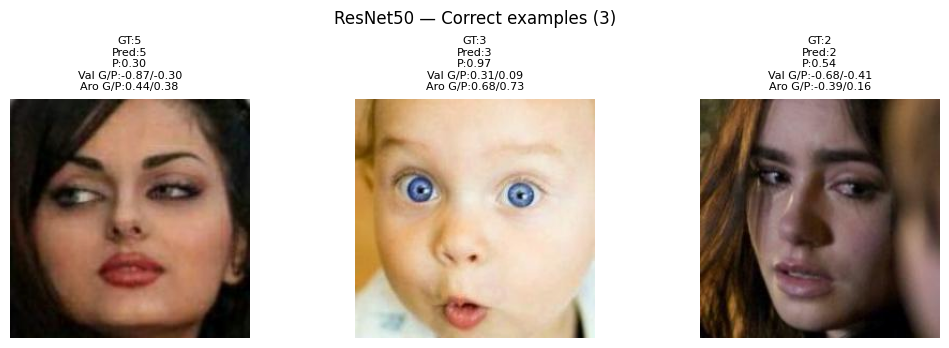

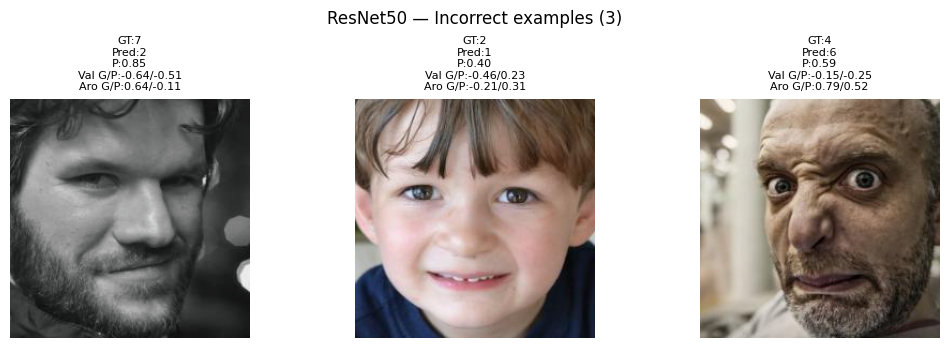


--- EfficientNet-B3 ---


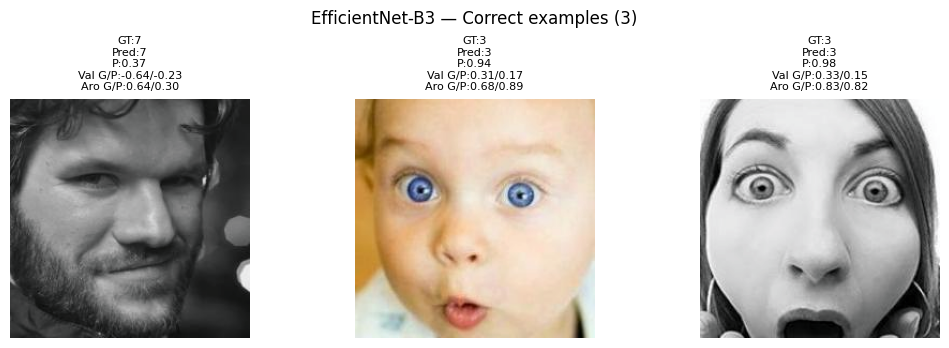

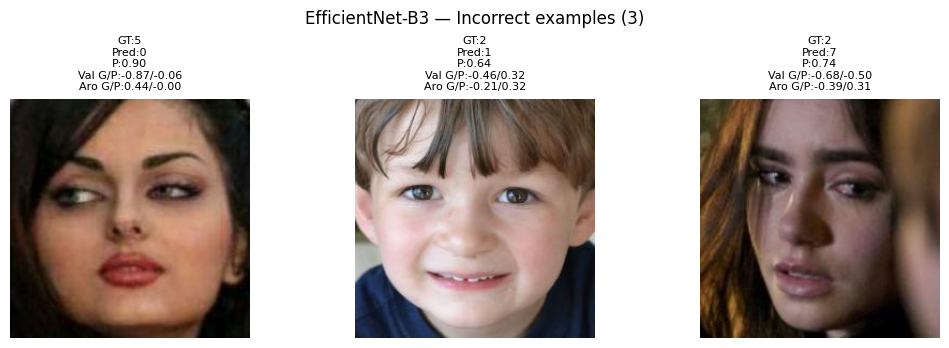


--- VGG16 ---


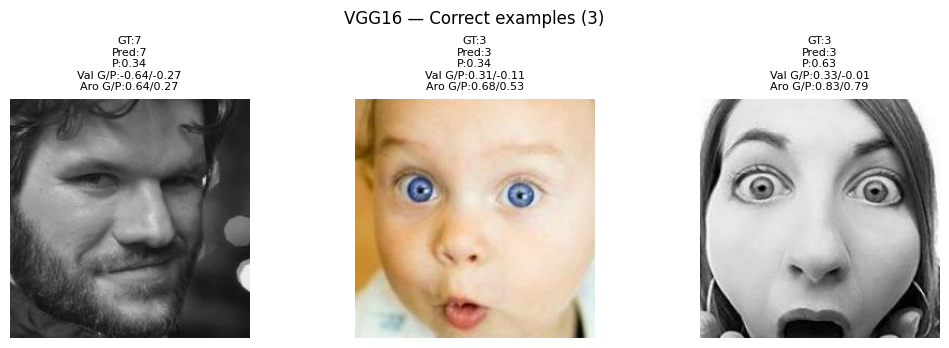

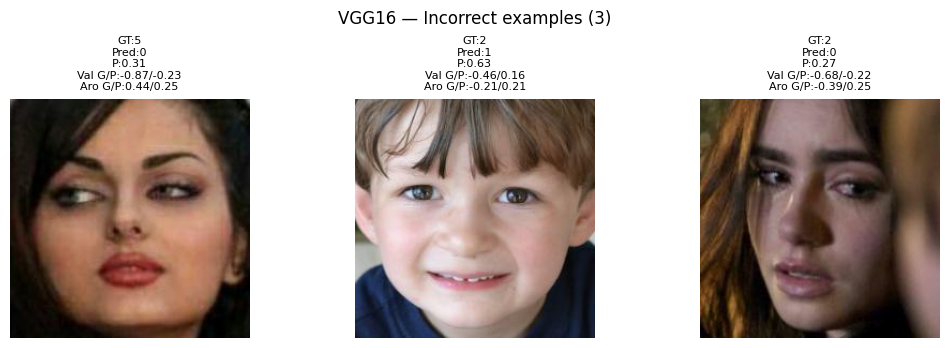


--- MobileNet-V2 ---


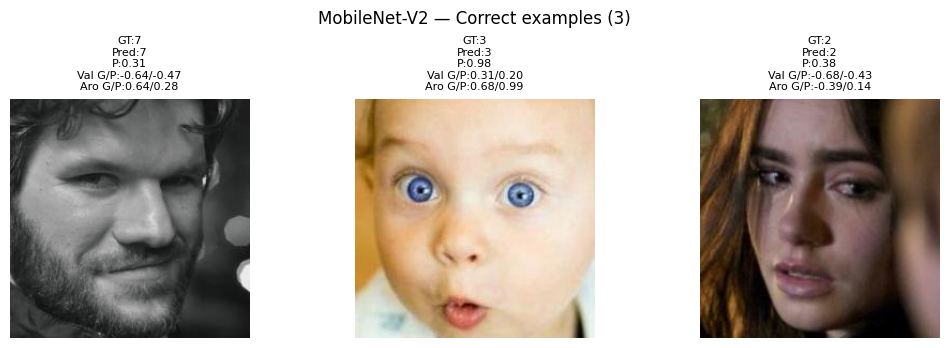

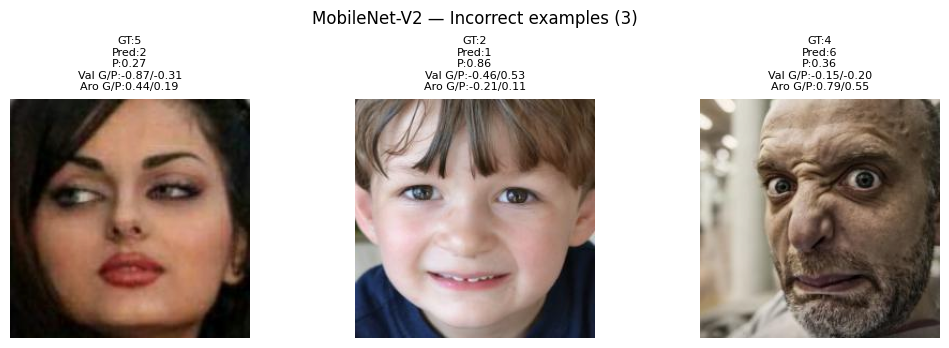

In [17]:
# Simple qualitative testing cell for 4 models
# Paste and run. Assumes you already have: val_loader, MultiTaskModel, DEVICE, NUM_CLASSES, and torchvision transforms.

import os, torch, numpy as np
import matplotlib.pyplot as plt
from math import ceil

# --- Config: checkpoints (change paths if needed) ---
MODEL_CKPTS = {
    "ResNet50": "./best_resnet50.pth",
    "EfficientNet-B3": "./best_efficientnet_b3.pth",
    "VGG16": "./best_vgg16.pth",
    "MobileNet-V2": "./best_mobilenet_v2.pth",
}
# How many examples to show per type
N_SHOW = 3

# optional label map (replace with your emotion names if available)
label_map = None
# label_map = {0:"neutral",1:"happy",2:"sad",3:"surprise",4:"fear",5:"disgust",6:"anger",7:"contempt"}

def unnormalize(img_tensor):
    """Convert CxHxW normalized torch tensor -> HxWx3 uint8 numpy for plotting (ImageNet mean/std)."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1,2,0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

def try_load_model(ckpt_path, backbone_name):
    if not os.path.exists(ckpt_path):
        print(f"[SKIP] checkpoint not found: {ckpt_path}")
        return None
    # prefer user helper if available
    if 'prepare_model_from_checkpoint' in globals():
        try:
            m, *_ = prepare_model_from_checkpoint(ckpt_path, backbone_name, cleaned_out_path=None, device=DEVICE)
            m.to(DEVICE).eval()
            return m
        except Exception:
            pass
    # fallback simple load (trusted local checkpoint)
    try:
        # PyTorch 2.6+ may accept weights_only=False; try it
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
    except Exception as e:
        print("Failed to load checkpoint:", e)
        return None

    if isinstance(ckpt, dict):
        if "model_state" in ckpt:
            sd = ckpt["model_state"]
        elif "state_dict" in ckpt:
            sd = ckpt["state_dict"]
        else:
            sd = ckpt
    else:
        print("Unrecognized checkpoint format:", type(ckpt))
        return None

    # sanitize keys from DataParallel
    sd_sanitized = {}
    for k,v in sd.items():
        nk = k[len("module."):] if k.startswith("module.") else k
        sd_sanitized[nk] = v

    model = MultiTaskModel(backbone_name=backbone_name.replace("-", "_").lower(), pretrained=False).to(DEVICE)
    model.load_state_dict(sd_sanitized, strict=False)
    model.eval()
    return model

# iterate models
for model_name, ckpt_path in MODEL_CKPTS.items():
    print("\n---", model_name, "---")
    # normalize backbone name mapping for MultiTaskModel usage
    bk = model_name.lower().replace("-", "_")
    if "efficientnet" in bk and "b3" in bk:
        backbone_arg = "efficientnet_b3"
    elif "efficientnet" in bk and "b0" in bk:
        backbone_arg = "efficientnet_b0"
    elif "resnet" in bk:
        backbone_arg = "resnet50"
    elif "vgg" in bk:
        backbone_arg = "vgg16"
    elif "mobilenet" in bk:
        backbone_arg = "mobilenet_v2"
    else:
        backbone_arg = bk

    model = try_load_model(ckpt_path, backbone_arg)
    if model is None:
        print(f"Could not load {model_name}; skipping.")
        continue

    correct_examples = []
    incorrect_examples = []

    # run through val_loader until we have enough examples
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(DEVICE)
            labels = batch["exp"].cpu().numpy()
            val_gt = batch["valence"].cpu().numpy()
            aro_gt = batch["arousal"].cpu().numpy()

            logits, regs = model(imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            regs_np = regs.cpu().numpy()

            bs = imgs.size(0)
            for i in range(bs):
                info = {
                    "img": imgs[i].cpu(),
                    "gt": int(labels[i]),
                    "pred": int(preds[i]),
                    "prob": float(probs[i][preds[i]]),
                    "val_gt": float(val_gt[i]),
                    "val_pred": float(regs_np[i,0]),
                    "aro_gt": float(aro_gt[i]),
                    "aro_pred": float(regs_np[i,1]),
                }
                if info["gt"] == info["pred"]:
                    if len(correct_examples) < N_SHOW:
                        correct_examples.append(info)
                else:
                    if len(incorrect_examples) < N_SHOW:
                        incorrect_examples.append(info)
            if len(correct_examples) >= N_SHOW and len(incorrect_examples) >= N_SHOW:
                break

    # plotting
    def label_name(idx):
        return label_map[idx] if (label_map and idx in label_map) else str(idx)

    # show correct
    n = max(1, max(len(correct_examples), len(incorrect_examples)))
    cols = max(1, N_SHOW)
    # Correct row
    if correct_examples:
        plt.figure(figsize=(cols*3.5, 3.5))
        for i, ex in enumerate(correct_examples):
            ax = plt.subplot(1, cols, i+1)
            ax.imshow(unnormalize(ex["img"]))
            ax.axis("off")
            ax.set_title(f"GT:{label_name(ex['gt'])}\nPred:{label_name(ex['pred'])}\nP:{ex['prob']:.2f}\nVal G/P:{ex['val_gt']:.2f}/{ex['val_pred']:.2f}\nAro G/P:{ex['aro_gt']:.2f}/{ex['aro_pred']:.2f}", fontsize=8)
        plt.suptitle(f"{model_name} — Correct examples ({len(correct_examples)})")
        plt.tight_layout()
        plt.show()
    else:
        print("No correct examples found in validation for this model.")

    # Incorrect row
    if incorrect_examples:
        plt.figure(figsize=(cols*3.5, 3.5))
        for i, ex in enumerate(incorrect_examples):
            ax = plt.subplot(1, cols, i+1)
            ax.imshow(unnormalize(ex["img"]))
            ax.axis("off")
            ax.set_title(f"GT:{label_name(ex['gt'])}\nPred:{label_name(ex['pred'])}\nP:{ex['prob']:.2f}\nVal G/P:{ex['val_gt']:.2f}/{ex['val_pred']:.2f}\nAro G/P:{ex['aro_gt']:.2f}/{ex['aro_pred']:.2f}", fontsize=8)
        plt.suptitle(f"{model_name} — Incorrect examples ({len(incorrect_examples)})")
        plt.tight_layout()
        plt.show()
    else:
        print("No incorrect examples found in validation for this model.")
